## Setup: encoding the 48 election states

Quick recap of the objects from the post. With three candidates $A, B, C$ there
are three head-to-head matchups. Each matchup has a **margin**: the fraction of
voters preferring one candidate minus the fraction preferring the other. (A
margin of $+4\%$ in the $A$-vs-$B$ matchup means $A$ wins that matchup 52–48.)

An election **state** records (i) who wins each matchup and (ii) which matchup
is closest, middle, and widest — giving $8 \times 6 = 48$ states. The code
below encodes all 48, plus the six special states from the post (for a
coalition of voters who all rank $A \succ B \succ C$): the two **gates**
$G_1, G_2$ where a single coordinated lie profitably flips the winner, and the
four states that can *reach* a gate through a chain of lies.

In [1]:
import math
import numpy as np
import pandas as pd
from itertools import permutations
from scipy.special import ndtr   # standard normal CDF

rng = np.random.default_rng(2026)

# Margin columns: 0 = A-vs-B, 1 = B-vs-C, 2 = C-vs-A.
# Sign convention: mAB > 0 means A beats B; mBC > 0 means B beats C;
# mCA > 0 means C beats A.
pos_pair = [('A','B'), ('B','C'), ('C','A')]   # (winner, loser) if margin > 0
neg_pair = [('B','A'), ('C','B'), ('A','C')]   # (winner, loser) if margin < 0
perms3 = list(permutations([0, 1, 2]))

def state_tuple(order, signs):
    return tuple(pos_pair[c] if signs[c] > 0 else neg_pair[c] for c in order)

def is_cyclic(state):
    wins = {c: set() for c in 'ABC'}
    for w, l in state:
        wins[w].add(l)
    return not any(wins[c] == {'A','B','C'} - {c} for c in 'ABC')

# Look-up tables over all 48 states, indexed by (magnitude order, sign pattern)
cyclic_lut = np.zeros((6, 8), dtype=bool)
tuple_to_code = {}
for oi, order in enumerate(perms3):
    for sc in range(8):
        signs = [1 if (sc >> k) & 1 else -1 for k in range(3)]
        st = state_tuple(order, signs)
        cyclic_lut[oi, sc] = is_cyclic(st)
        tuple_to_code[st] = (oi, sc)

# The six named states for the coalition A > B > C (verbatim from the post),
# with the chain "depth": how many rank-steps the lie must push the margins.
G1            = (('C','B'), ('B','A'), ('A','C'))
G2            = (('B','C'), ('A','B'), ('C','A'))
start1        = (('B','A'), ('A','C'), ('B','C'))
start2        = (('B','A'), ('B','C'), ('A','C'))
start3        = (('B','C'), ('B','A'), ('A','C'))
startBetrayal = (('B','C'), ('C','A'), ('A','B'))

named = [('start1', start1, 4), ('start2', start2, 3), ('start3', start3, 2),
         ('G1', G1, 1), ('betrayal start', startBetrayal, 2), ('G2', G2, 1)]
BURIAL_IDS = {0, 1, 2, 3}          # states manipulated by the C>B "burial" lie
GATE_IDS = {3, 5}                  # G1 and G2

state_id_lut = np.full((6, 8), -1, dtype=int)
for sid, (_, st, _) in enumerate(named):
    oi, sc = tuple_to_code[st]
    state_id_lut[oi, sc] = sid

_perm_arr = np.array(perms3)
_lut27 = np.zeros(27, dtype=int)
for i, row in enumerate(_perm_arr):
    _lut27[row[0]*9 + row[1]*3 + row[2]] = i

def classify(mAB, mBC, mCA):
    '''For arrays of margins, return (is_cyclic, state_id) where state_id
    indexes the six named states (-1 = any other state).'''
    M = np.stack([mAB, mBC, mCA], axis=1)
    order = np.argsort(np.abs(M), axis=1)
    oi = _lut27[order[:,0]*9 + order[:,1]*3 + order[:,2]]
    sc = (mAB > 0).astype(int) + 2*(mBC > 0).astype(int) + 4*(mCA > 0).astype(int)
    return cyclic_lut[oi, sc], state_id_lut[oi, sc]

## The cast of voter models

Since real elections don't come with a known probability distribution, we
simulate several standard ones, from least to most realistic:

- **Impartial Culture (IC).** Every voter independently picks one of the 6
  possible rankings of $A, B, C$ uniformly at random — like rolling a fair die.
  This is the classic worst-case benchmark: maximal disagreement, elections
  perpetually on a knife's edge. We run it at two electorate sizes ($n = 1{,}001$
  and $n = 10{,}001$ voters) because, unusually, the *size* of the electorate
  matters for IC: its margins shrink like $1/\sqrt{n}$.
- **Impartial Anonymous Culture (IAC).** Instead of each voter rolling a die,
  the *society-wide shares* of the 6 rankings are drawn uniformly at random.
  This builds in correlation between voters (whole populations lean one way or
  another) and produces realistic, non-tiny margins.
- **Mallows model.** Voters mostly agree with a common ranking
  ($A \succ B \succ C$) but each voter's ranking is randomly perturbed. A
  dispersion knob $\varphi$ runs from perfect agreement to IC; we set
  $\varphi = 0.97$, mild consensus.
- **2D spatial model.** Voters live in a 2-dimensional "ideology space" grouped
  into 3 random clusters (think: factions); candidates are random points; every
  voter prefers closer candidates. This is the workhorse model behind most
  modern voting simulations. We compute its margins exactly (infinitely many
  voters), so its randomness comes purely from where the candidates and
  factions land.

For each model we also track the **pool**: the fraction of voters whose sincere
ranking is exactly $A \succ B \succ C$. As shown in the post, these are the
*only* voters who both benefit from and are positioned to execute either
manipulation — so the pool is the manipulation's recruitment ceiling.

In [2]:
# Pairwise-vote vectors for the 6 rankings, in the order
# ABC, ACB, BAC, BCA, CAB, CBA  (so index 0 = the coalition's ranking)
Y_AB = np.array([ 1,  1, -1, -1,  1, -1], dtype=float)
Y_BC = np.array([ 1, -1,  1,  1, -1, -1], dtype=float)
Y_CA = np.array([-1, -1, -1,  1,  1,  1], dtype=float)

cultures = {}   # name -> dict(mAB, mBC, mCA [fractions], pool)

def add_ranking_culture(name, weights, n_voters, N):
    '''Cultures where we literally simulate n_voters ballots N times.'''
    counts = rng.multinomial(n_voters, weights, size=N)
    mAB, mBC, mCA = (counts @ Y_AB, counts @ Y_BC, counts @ Y_CA)
    # discard exact ties (rare, and merely a knife-edge technicality)
    keep = (mAB != 0) & (mBC != 0) & (mCA != 0)
    keep &= ((np.abs(mAB) != np.abs(mBC)) & (np.abs(mBC) != np.abs(mCA))
             & (np.abs(mAB) != np.abs(mCA)))
    cultures[name] = dict(
        mAB=mAB[keep]/n_voters, mBC=mBC[keep]/n_voters, mCA=mCA[keep]/n_voters,
        pool=counts[keep, 0]/n_voters)

N = 500_000
add_ranking_culture('IC, 1,001 voters',  np.full(6, 1/6), 1001,  N)
add_ranking_culture('IC, 10,001 voters', np.full(6, 1/6), 10001, N)

phi = 0.97
w = phi ** np.array([0, 1, 1, 2, 2, 3]); w /= w.sum()
add_ranking_culture('Mallows (mild consensus)', w, 1001, N)

# IAC: society-wide ranking shares uniform on the simplex (Dirichlet(1,..,1));
# with many voters the margins are then determined by the shares.
P = rng.dirichlet(np.ones(6), size=2*N)
cultures['IAC'] = dict(mAB=P @ Y_AB, mBC=P @ Y_BC, mCA=P @ Y_CA, pool=P[:, 0])

# 2D spatial model: 3 Gaussian voter clusters, Gaussian candidates.
# Each matchup's vote share is an exact Gaussian half-plane measure
# (the perpendicular bisector of two candidates splits the plane).
K, tau, s, Nsp = 3, 1.0, 0.5, 400_000
cand    = rng.normal(0, 1,   size=(Nsp, 3, 2))
centers = rng.normal(0, tau, size=(Nsp, K, 2))
wts     = rng.dirichlet(np.ones(K), size=Nsp)

def spatial_margin(ci, cj):
    a = 2*(cj - ci)
    b = (cj**2).sum(axis=1) - (ci**2).sum(axis=1)
    z = (b[:, None] - np.einsum('nd,nkd->nk', a, centers)) \
        / (s * np.linalg.norm(a, axis=1)[:, None])
    return 2*(wts * ndtr(z)).sum(axis=1) - 1

A_, B_, C_ = cand[:, 0], cand[:, 1], cand[:, 2]
sp = dict(mAB=spatial_margin(A_, B_), mBC=spatial_margin(B_, C_),
          mCA=spatial_margin(C_, A_))

# The spatial pool (share of voters ranking A > B > C) has no simple formula,
# so estimate it by sampling voters -- but only for elections that land in
# one of the six states (the only place we need it).
_, sid_sp = classify(sp['mAB'], sp['mBC'], sp['mCA'])
pool = np.full(Nsp, np.nan)
hits, V = np.flatnonzero(sid_sp >= 0), 500
for lo in range(0, len(hits), 5000):
    idx = hits[lo:lo+5000]
    cid = (rng.random((len(idx), V, 1))
           > np.cumsum(wts[idx], axis=1)[:, None, :]).sum(axis=2)
    mu = np.take_along_axis(centers[idx], cid[:, :, None], axis=1)
    x = mu + rng.normal(0, s, size=(len(idx), V, 2))
    d2 = ((x[:, :, None, :] - cand[idx][:, None, :, :])**2).sum(axis=3)
    pool[idx] = ((d2[:,:,0] < d2[:,:,1]) & (d2[:,:,1] < d2[:,:,2])).mean(axis=1)
sp['pool'] = pool
cultures['2D spatial (3 factions)'] = sp

print('simulated cultures:', ', '.join(cultures))

simulated cultures: IC, 1,001 voters, IC, 10,001 voters, Mallows (mild consensus), IAC, 2D spatial (3 factions)


## Question 1: How often do manipulable states occur at all?

For each model we measure the share of elections that are:

- a **cycle** (no Condorcet winner — every candidate loses some matchup),
- one of the **2 gates** — the only states where a *single* profitable lie
  exists for our coalition,
- one of the **6 states** from which *some* chain of lies eventually profits
  the coalition (the gates plus the four chain-start states).

For calibration: the theoretical cycle rate under IC with a huge electorate is
Guilbaud's classic $\tfrac14 - \tfrac{3}{2\pi}\arcsin\tfrac13 \approx 8.77\%$,
and under IAC it is exactly $1/16 = 6.25\%$.

In [3]:
rows = []
for name, cu in cultures.items():
    cyc, sid = classify(cu['mAB'], cu['mBC'], cu['mCA'])
    rows.append({
        'model': name,
        'P(cycle)':          f"{cyc.mean()*100:.2f}%",
        'P(at a gate)':      f"{np.isin(sid, list(GATE_IDS)).mean()*100:.3f}%",
        'P(any of the six)': f"{(sid >= 0).mean()*100:.2f}%",
    })
pd.DataFrame(rows).set_index('model')

,P(cycle),P(at a gate),P(any of the six)
model,,,
"IC, 1,001 voters",8.25%,1.393%,9.74%
"IC, 10,001 voters",8.65%,1.482%,9.84%
Mallows (mild consensus),5.86%,0.920%,14.18%
IAC,6.26%,1.037%,9.37%
2D spatial (3 factions),0.11%,0.017%,10.26%


**What this says, in plain terms:** even under impartial culture — the model
*designed* to produce chaotic elections — the coalition finds itself at a gate
(the only place a single lie profits) in **about 1.4% of elections**, roughly 1
in 70. Under the more realistic spatial model that collapses to **about 0.02%
— roughly 1 in 5,000 elections**. Cycles themselves follow the same pattern:
common-ish in the deliberately chaotic models (6–9%), nearly nonexistent
(≈0.1%) once voters have any ideological structure. The "any of the six"
column stays near 10% everywhere, but as Questions 2 and 3 show, most of that
10% is opportunity on paper only.

Thus far, cycles have been [empirically rare](https://electowiki.org/wiki/Condorcet_paradox#Known_Condorcet_cycles) and "common in small elections or where the outcome is sufficiently close to a tie that they can be produced by noise." 

## Question 2: Could you even *know* you're in a manipulable state?

Manipulating requires knowing the state of the race — which matchup is
closest, which is second — *before election day*. That means polling.

For each election we compute how far its margins sit from the nearest
"boundary": the smallest change that would flip a matchup's winner or swap two
matchups' closeness ranking. Call this the **identification radius**
$\varepsilon$. If polls can't measure margins to within $\varepsilon$, the
coalition *cannot tell which state it's in* — it might lie in an election
where the lie backfires.

How precise are real polls? [Shirani-Mehr, Rothschild, Goel & Gelman (2018)](https://doi.org/10.1080/01621459.2018.1448823)
analyzed 4,221 polls across 608 US state-level races and found the typical
error on a poll's *margin* is about **3.5 percentage points** — roughly twice
the "margin of error" polls report, because real polls have errors beyond
random sampling. We use 3.5% as the realistic single-poll noise floor, and 1%
as an optimistic floor for a well-aggregated polling average.

In [4]:
rows = []
for name, cu in cultures.items():
    M = np.abs(np.stack([cu['mAB'], cu['mBC'], cu['mCA']], axis=1))
    M.sort(axis=1)                                  # |m1| <= |m2| <= |m3|
    eps = np.minimum(M[:,0], np.minimum(M[:,1]-M[:,0], M[:,2]-M[:,1]))
    _, sid = classify(cu['mAB'], cu['mBC'], cu['mCA'])
    g = np.isin(sid, list(GATE_IDS))                # condition on gate states
    rows.append({
        'model': name,
        'closest matchup': f"{np.median(M[g,0])*100:.2f}%",
        'middle matchup':  f"{np.median(M[g,1])*100:.2f}%",
        'widest matchup':  f"{np.median(M[g,2])*100:.2f}%",
        'identification radius': f"{np.median(eps[g])*100:.2f}%",
        'hidden below 3.5% poll noise': f"{(eps[g] < 0.035).mean()*100:.0f}%",
        'hidden below 1% aggregate':    f"{(eps[g] < 0.01).mean()*100:.0f}%",
    })
pd.DataFrame(rows).set_index('model')

,closest matchup,middle matchup,widest matchup,identification radius,hidden below 3.5% poll noise,hidden below 1% aggregate
model,,,,,,
"IC, 1,001 voters",0.50%,1.30%,2.70%,0.30%,100%,99%
"IC, 10,001 voters",0.13%,0.41%,0.85%,0.07%,100%,100%
Mallows (mild consensus),0.50%,1.30%,2.90%,0.30%,100%,99%
IAC,4.28%,12.93%,29.20%,2.18%,69%,27%
2D spatial (3 factions),1.68%,5.11%,11.52%,1.06%,91%,44%


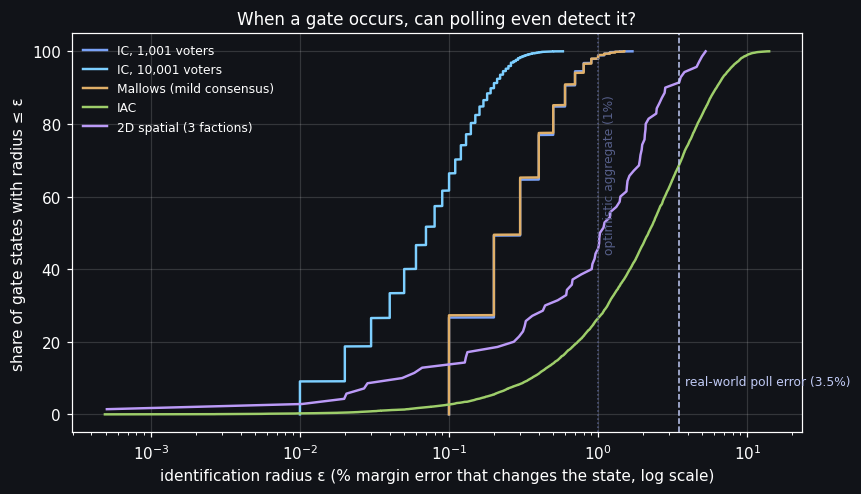

In [5]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 4.6), dpi=110)
fig.patch.set_facecolor('#111318'); ax.set_facecolor('#111318')
colors = ['#7aa2f7', '#7dcfff', '#e0af68', '#9ece6a', '#bb9af7']
for (name, cu), col in zip(cultures.items(), colors):
    M = np.abs(np.stack([cu['mAB'], cu['mBC'], cu['mCA']], axis=1)); M.sort(axis=1)
    eps = np.minimum(M[:,0], np.minimum(M[:,1]-M[:,0], M[:,2]-M[:,1]))
    _, sid = classify(cu['mAB'], cu['mBC'], cu['mCA'])
    e = np.sort(eps[np.isin(sid, list(GATE_IDS))])
    ax.plot(e*100, np.arange(1, len(e)+1)/len(e)*100, color=col, lw=1.6, label=name)
ax.axvline(3.5, color='#c0caf5', ls='--', lw=1)
ax.text(3.8, 8, 'real-world poll error (3.5%)', color='#c0caf5', fontsize=8)
ax.axvline(1.0, color='#565f89', ls=':', lw=1)
ax.text(1.08, 45, 'optimistic aggregate (1%)', color='#565f89', fontsize=8, rotation=90)
ax.set_xscale('log')
ax.set_xlabel('identification radius ε (% margin error that changes the state, log scale)')
ax.set_ylabel('share of gate states with radius ≤ ε')
ax.set_title('When a gate occurs, can polling even detect it?', fontsize=11)
ax.legend(frameon=False, fontsize=8, loc='upper left')
ax.grid(alpha=0.15)
plt.tight_layout(); plt.show()

**What this says, in plain terms:** when a gate state *does* occur, it looks
like a race decided by eyelashes. Under IC with 1,001 voters, the median gate
has its closest matchup at about half a percentage point and the whole state
identifiable only with sub-half-point polling — and **essentially 100% of gate
states are invisible at realistic polling precision** (curves far left of the
dashed line). Even under IAC, where margins are healthier, about **two-thirds
of gates hide below single-poll noise**. The pattern is a genuine catch-22
that we'll make exact in Question 3: The cheaper the manipulation, the more invisible it is.

## Question 3: How many voters would have to lie?

Suppose the coalition somehow *did* have perfect knowledge. How many insincere
ballots does the manipulation take?

Every deviating voter flips their vote in exactly one matchup, moving that
margin by $2$ votes. Working through each of the six states (details in the
post), the minimal deviating fraction of the electorate has a closed form:

$$\delta^* = \tfrac{1}{2}\,(m_{BC} - m_{AB}) \;\;\text{(burial states)}, \qquad
  \delta^* = \tfrac{1}{2}\,(m_{AB} - m_{BC}) \;\;\text{(betrayal states)}.$$

At a gate this is exactly *half the gap between the two closest matchups* —
which is (up to a factor of 2) the same quantity as Question 2's
identification radius. **Cost and required precision are two faces of the same
coin: a manipulation is cheap exactly when the state is unknowable.**

The deviators must also come from somewhere: only voters who sincerely rank
$A \succ B \succ C$ both benefit from and can execute the lie. So we compare
$\delta^*$ to that pool and call the manipulation **feasible** only if the
pool is big enough.

In [6]:
rows = []
for name, cu in cultures.items():
    _, sid = classify(cu['mAB'], cu['mBC'], cu['mCA'])
    delta = np.full(len(sid), np.nan)
    bur = np.isin(sid, list(BURIAL_IDS)); bet = (sid >= 4)
    delta[bur] = (cu['mBC'][bur] - cu['mAB'][bur]) / 2
    delta[bet] = (cu['mAB'][bet] - cu['mBC'][bet]) / 2
    six, gates = (sid >= 0), np.isin(sid, list(GATE_IDS))
    ratio = np.divide(delta, cu['pool'],
                      out=np.full_like(delta, np.inf), where=cu['pool'] > 0)
    rows.append({
        'model': name,
        'median cost, at gates': f"{np.median(delta[gates])*100:.2f}%",
        'median cost, any of six': f"{np.median(delta[six])*100:.1f}%",
        'median share of coalition needed': f"{np.median(ratio[six])*100:.0f}%",
        'P(coalition big enough)': f"{(ratio[six] <= 1).mean()*100:.0f}%",
    })
pd.DataFrame(rows).set_index('model')

,"median cost, at gates","median cost, any of six",median share of coalition needed,P(coalition big enough)
model,,,,
"IC, 1,001 voters",0.30%,1.7%,10%,100%
"IC, 10,001 voters",0.10%,0.5%,3%,100%
Mallows (mild consensus),0.30%,2.4%,14%,100%
IAC,3.30%,22.1%,121%,41%
2D spatial (3 factions),1.39%,53.6%,239%,11%


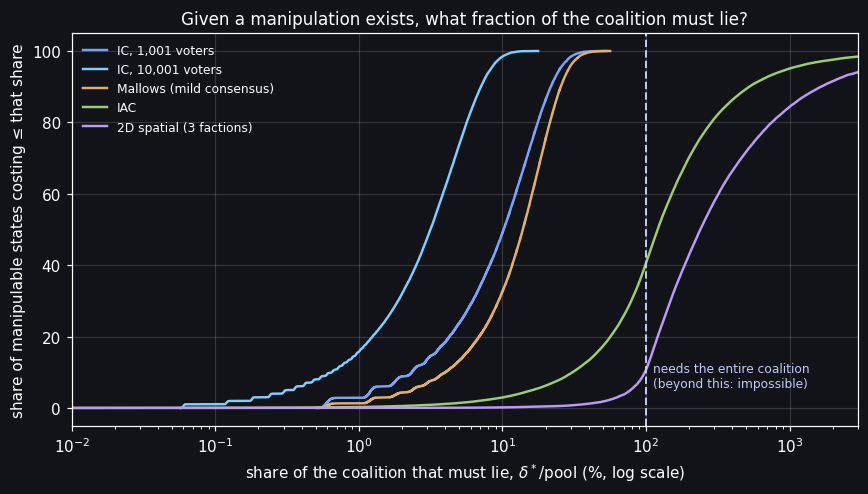

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.6), dpi=110)
fig.patch.set_facecolor('#111318'); ax.set_facecolor('#111318')
for (name, cu), col in zip(cultures.items(), colors):
    _, sid = classify(cu['mAB'], cu['mBC'], cu['mCA'])
    delta = np.full(len(sid), np.nan)
    bur = np.isin(sid, list(BURIAL_IDS)); bet = (sid >= 4)
    delta[bur] = (cu['mBC'][bur] - cu['mAB'][bur]) / 2
    delta[bet] = (cu['mAB'][bet] - cu['mBC'][bet]) / 2
    six = (sid >= 0)
    # ratio = share of the *coalition* (not the electorate) that must lie;
    # a pool of 0 makes the manipulation impossible outright (ratio = inf).
    ratio = np.divide(delta, cu['pool'],
                      out=np.full_like(delta, np.inf), where=cu['pool'] > 0)
    r = np.sort(ratio[six])
    n = len(r)
    finite = np.isfinite(r)
    # CDF denominator is the full count `n`, so curves that hit an infeasible
    # (infinite-ratio) state simply stop short of 100% on the y-axis.
    ax.plot(r[finite]*100, (np.flatnonzero(finite)+1) * 100 / n, color=col, lw=1.6, label=name)
ax.axvline(100, color='#c0caf5', ls='--', lw=1.3)
ax.text(112, 6, 'needs the entire coalition\n(beyond this: impossible)', color='#c0caf5', fontsize=8)
ax.set_xscale('log')
ax.set_xlim(1e-2, 3000)   # a rare tail of extreme outliers (tiny pools) runs off-chart
ax.set_xlabel(r'share of the coalition that must lie, $\delta^*/\mathrm{pool}$ (%, log scale)')
ax.set_ylabel('share of manipulable states costing ≤ that share')
ax.set_title('Given a manipulation exists, what fraction of the coalition must lie?', fontsize=11)
ax.legend(frameon=False, fontsize=8, loc='upper left')
ax.grid(alpha=0.15)
plt.tight_layout(); plt.show()

**What this says, in plain terms:** under impartial culture the lie is cheap, but then exactly in the elections nobody can read. Under
the realistic models the picture inverts: costs balloon. (only
**~40% of manipulable states have a feasible manipulation under IAC** across the six states, and under **~10% under the spatial model**). In most cases **the coalition simply isn't big
enough**.

Note the IC rows at two
electorate sizes: bigger electorates make the lie *cheaper* (margins shrink
like $1/\sqrt{n}$) while making the state proportionally *harder to detect*.